# NERVE Raw Data Conversion

Session archives from 4TU contain sensor data in vendor-specific binary
formats. Before event representations, label extraction, or dataset generation
can run, these raw recordings must be converted to the standardised HDF5 format
that all downstream code expects.

This notebook walks through **every conversion step** in the pipeline:

| # | Source | Sensor | Target | Module |
|---|--------|--------|--------|--------|
| 1 | `.rad` (TLV binary) | Infineon Position2Go + DAVIS346 | `events.hdf5` (DAVIS346 events) | `nerve.extraction.access.radar_dvs` |
| 2 | `.raw` (Metavision) | Prophesee EVK4 | `events.hdf5` | `nerve.extraction.access.raw_to_hdf5` |
| 3 | `data.h5` (ADC) | TI AWR1443BOOST | Point clouds / range-Doppler | `nerve.radar` |
| 4 | `.mp4` (H.264) | L515 RGB | BGR frames | OpenCV |
| 5 | `.mp4` (gray16le) | L515 depth | 16-bit depth arrays | `ffmpegReaders` |
| 6 | `events.hdf5` | DAVIS / EVK4 | Reconstructed images | `nerve.extraction.reconstruction` |

> **Prerequisites:** The first code cell downloads the smallest available session automatically.
> Some conversions require optional dependencies -- each section notes what is needed.

In [1]:
from nerve import config, remote
from nerve.registry import all_sessions
from pathlib import Path
import json

sessions = all_sessions()
smallest = min(sessions, key=lambda s: s.size_bytes)
print(f"Smallest session: {smallest.name}  "
      f"({smallest.size_bytes / 1e9:.2f} GB archive, split={smallest.split})")

SESSION_DIR = Path(remote.download_session(smallest.name))
print(f"Session directory: {SESSION_DIR}")
print(f"Contents: {sorted(p.name for p in SESSION_DIR.iterdir())}")


Smallest session: 2023-10-26_15-37-59  (0.40 GB archive, split=train)
  Session already exists: /gpfs/home5/omansour/.nerve/data/2023-10-26_15-37-59
Session directory: /gpfs/home5/omansour/.nerve/data/2023-10-26_15-37-59
Contents: ['L515_depth.mp4', 'L515_depth_confidence.mp4', 'L515_depth_unit.txt', 'L515_rgb.txt', 'davis', 'evk4_events.bias', 'evk4_events.hdf5', 'infineon_radar', 'prophesee', 'radar_and_davis346_events.rad', 'rgb', 'session_metadata.json', 'ti_radar', 'timings.json']


---
## 1. DAVIS346: `.rad` to HDF5

The DAVIS346 event camera records alongside the **Infineon Position2Go** radar
into a combined `.rad` binary file using a proprietary recording
system. This is a **TLV (type-length-value)** format where
Infineon radar ADC frames and DAVIS346 polarity events are multiplexed into
the same byte stream.

> **Note:** The TI AWR1443BOOST mmWave radar records separately into
> `ti_radar/captured_data/set000/data.h5` -- it is **not** part of the `.rad` file.

### How the `.rad` parser works

The `RadarFileParser` in `nerve.extraction.access.radar_dvs.rad_file_parser`:

1. Opens the binary `.rad` stream and iterates over TLV headers.
2. Separates Infineon radar frames (`rafd` tag) from DAVIS346 polarity
   packets (`polb` tag).
3. For the HDF5 converter, only the polarity packets are used: it extracts
   `(timestamp, x, y, polarity)` tuples from each `polb` payload.
4. Accumulates all events across the file.

The parser also exposes Infineon radar frames via
`RadarFileParser.radar_frames` for applications that need the raw Infineon
ADC data.

The converter `rad_polarities_to_hdf5.py` then:

1. Collects all extracted events into numpy arrays.
2. Writes them as a single gzip-compressed `events` dataset in HDF5.
3. Stores camera attributes: `width=346`, `height=260`, `total_events=N`.
4. Optionally builds a **support index** -- a lookup table mapping quantised
   timestamps (e.g. every 100 µs) to event array indices, enabling O(1)
   random access by time window.

### Output HDF5 structure

```
davis/events.hdf5
├── events              (N, 4) int64   -- [t_us, x, y, polarity]
├── support_indexes     (M,)   int64   -- optional time-to-index map
└── attrs:
    ├── width:  346
    ├── height: 260
    └── total_events: N
```

In [24]:
# Examine the converted DAVIS HDF5 (already present in the session archive)
import h5py
import numpy as np

davis_hdf5 = SESSION_DIR / "davis" / "events.hdf5"
if davis_hdf5.exists():
    with h5py.File(davis_hdf5, "r") as f:
        print("=== DAVIS346 events.hdf5 ===")
        print(f"Datasets: {list(f.keys())}")
        print(f"Attributes: {dict(f.attrs)}")
        events = f["events"]
        print(f"Shape: {events.shape}, dtype: {events.dtype}")
        print(f"First 5 events (t_us, x, y, polarity):")
        print(events[:5])
        print(f"Duration: {(events[-1][0] - events[0][0]) / 1e6:.3f} s")
        if "support_indexes" in f:
            si = f["support_indexes"]
            print(f"\nSupport indexes: shape={si.shape}, enables O(1) time lookups")
else:
    print(f"Not found: {davis_hdf5}")
    print("The .rad file may need conversion first -- see CLI command below.")

=== DAVIS346 events.hdf5 ===
Datasets: ['events', 'support_indexes']
Attributes: {}
Shape: (459160,), dtype: {'names': ['t', 'x', 'y', 'p'], 'formats': ['<i8', '<u2', '<u2', 'i1'], 'offsets': [0, 8, 10, 12], 'itemsize': 16}
First 5 events (t_us, x, y, polarity):
[(249192803, 144, 176, 0) (249196832, 148, 164, 0)
 (249203535, 147, 167, 0) (249218637,  15, 220, 0)
 (249219124,  15, 217, 0)]
Duration: 14.483 s

Support indexes: shape=(144829,), enables O(1) time lookups


### Running the conversion

If you have a session with the raw `.rad` file but no `davis/events.hdf5`,
run the converter:

```bash
python -m nerve.extraction.access.radar_dvs.rad_polarities_to_hdf5 \
    -i /path/to/session/radar_and_davis346_events.rad \
    -o /path/to/session/davis/events.hdf5
```

| Flag | Effect |
|------|--------|
| `--avoid-support-indexes` | Skip building the time-to-index lookup (faster, smaller file) |
| `--support-period-us N` | Granularity of the support index in microseconds (default: 100) |

---
## 2. Prophesee EVK4: `.raw` to HDF5

The EVK4 HD event camera records in Prophesee's proprietary `.raw` format.
The `raw_to_hdf5.py` converter uses the **Metavision SDK** (`metavision_core`)
to iterate over the event stream and write an equivalent HDF5 file.

### How it works

1. Uses `EventsIterator` from `metavision_core.event_io` to stream events
   from the `.raw` file in fixed-size batches.
2. **First pass**: counts total events and computes the time range.
3. **Second pass**: writes events to a pre-allocated HDF5 dataset.
4. Stores camera attributes: `width=1280`, `height=720`, `sensor=PROPHESEE_EVK4`.
5. Optionally builds the same support-index structure as the DAVIS converter.

### Output HDF5 structure

```
prophesee/events.hdf5
├── events              (N, 4) int64   -- [t_us, x, y, polarity]
├── support_indexes     (M,)   int64   -- optional time-to-index map
└── attrs:
    ├── width:  1280
    ├── height: 720
    ├── sensor: PROPHESEE_EVK4
    └── total_events: N
```

> **Dependency:** Requires `metavision_core` from the
> [Prophesee OpenEB](https://github.com/prophesee-ai/openeb) package.
> This is a system-level install (not available via pip).

In [25]:
# Examine the converted EVK4 HDF5
evk4_hdf5 = SESSION_DIR / "prophesee" / "events.hdf5"
if evk4_hdf5.exists():
    with h5py.File(evk4_hdf5, "r") as f:
        print("=== EVK4 prophesee/events.hdf5 ===")
        print(f"Datasets: {list(f.keys())}")
        print(f"Attributes: {dict(f.attrs)}")
        events = f["events"]
        print(f"Shape: {events.shape}, dtype: {events.dtype}")
        print(f"First 5 events (t_us, x, y, polarity):")
        print(events[:5])
        print(f"Duration: {(events[-1][0] - events[0][0]) / 1e6:.3f} s")
else:
    print(f"Not found: {evk4_hdf5}")
    print("The .raw file may need conversion first (requires metavision_core).")

=== EVK4 evk4_events.hdf5 ===
Datasets: ['events', 'support_indexes']
Attributes: {}
Shape: (17236025,), dtype: {'names': ['x', 'y', 'p', 't'], 'formats': ['<u2', '<u2', '<i2', '<i8'], 'offsets': [0, 2, 4, 8], 'itemsize': 16}
First 5 events (t_us, x, y, polarity):
[( 752, 373, 1, 6272) ( 219, 370, 1, 6273) (1134, 299, 1, 6274)
 (1082,   5, 0, 6275) ( 113, 307, 1, 6276)]
Duration: 0.066 s


/scratch-local/74681/ipykernel_1514474/3667145962.py:12: RuntimeWarning: overflow encountered in scalar subtract
  print(f"Duration: {(events[-1][0] - events[0][0]) / 1e6:.3f} s")


### Running the conversion

```bash
python -m nerve.extraction.access.raw_to_hdf5 \
    -i /path/to/session/evk4_events.raw \
    -o /path/to/session/prophesee/events.hdf5
```

For **batch conversion** across multiple sessions:

```bash
bash nerve/extraction/access/prophesee_hdf5_converter.sh /path/to/data_root/
```

This shell script recursively finds all sessions under the given directory
and runs `raw_to_hdf5.py` for each `.raw` file.

---
## 3. TI AWR1443BOOST Radar: ADC to Point Clouds

The Texas Instruments AWR1443BOOST mmWave FMCW radar records raw ADC (Analog
to Digital Converter) data as a 6-dimensional tensor stored in HDF5. This is a
**separate** sensor from the Infineon Position2Go in the `.rad` file:

```
ti_radar/captured_data/set000/data.h5
└── shape: [frames, range_bins, TX_antennas, RX_antennas, chirps, IQ_components]
         = [N,      128,        3,           4,           256,    2]
```

### The FMCW processing chain

Converting raw ADC into usable outputs requires a multi-stage DSP pipeline:

1. **Range-FFT** -- FFT along the chirp (fast-time) axis → range profile.
2. **Doppler-FFT** -- FFT across chirps (slow-time) → range-Doppler map.
3. **CFAR detection** -- Constant False Alarm Rate threshold → candidate targets.
4. **Beamforming** -- Combine TX/RX antenna signals → angle-of-arrival.
5. **Point cloud** -- Each detection becomes `(x, y, z, velocity, SNR)`.

This chain is implemented by a proprietary third-party radar DSP library.
NERVE wraps it behind the abstract `RadarBackend` interface
([`nerve/radar/interface.py`](../nerve/radar/interface.py)) so that
alternative implementations can be substituted.

> **Dependency:** The underlying radar DSP library is proprietary and not
> included in the NERVE package. Users who do not have access to it can
> implement their own backend by subclassing `nerve.radar.RadarBackend`.
> See notebook `02_raw_data_exploration.ipynb` for conceptual background on
> FMCW radar DSP.

In [26]:
# Inspect the raw radar HDF5 structure
radar_h5 = SESSION_DIR / "ti_radar" / "captured_data" / "set000" / "data.h5"
if radar_h5.exists():
    with h5py.File(radar_h5, "r") as f:
        print("=== TI Radar data.h5 ===")
        def visitor(name, obj):
            if isinstance(obj, h5py.Dataset):
                print(f"  {name}: shape={obj.shape}, dtype={obj.dtype}")
            elif isinstance(obj, h5py.Group):
                print(f"  {name}/")
        f.visititems(visitor)
else:
    print(f"Not found: {radar_h5}")

=== TI Radar data.h5 ===
  radar/
  radar/dataset_1/
  radar/dataset_1/data: shape=(149, 128, 3, 4, 256, 2), dtype=int16
  radar/dataset_1/sequencenumbers: shape=(149,), dtype=uint64
  radar/dataset_1/timestamps: shape=(149,), dtype=float64
  radar/dataset_1/validflags: shape=(149,), dtype=uint8


In [27]:
# Try the RadarBackend (requires a registered radar DSP backend)
try:
    from nerve.radar import get_backend
    Backend = get_backend()
    radar = Backend.from_recording(str(SESSION_DIR / "ti_radar"))

    print(f"Radar frames: {radar.get_num_frames()}")
    pc = radar.get_point_cloud(0)
    print(f"Frame 0 point cloud: {pc.shape} (columns: x, y, z, velocity, snr)")

    rd = radar.get_range_doppler(0)
    print(f"Frame 0 range-Doppler map: {rd.shape}")

    radar.close()
except (ImportError, ValueError):
    print("No radar backend available -- install a DSP backend or implement your own.")
    print("The raw ADC data can still be read directly with h5py (see cell above).")
    print("Subclass nerve.radar.RadarBackend for custom DSP.")


Radar DSP library not installed — radar processing requires the proprietary library.
The raw ADC data can still be read directly with h5py (see cell above).
Implement your own RadarBackend subclass for custom DSP.


---
## 4. RGB Video: MP4 to Frames

RGB video from the Intel RealSense L515 is stored as `L515_rgb.mp4` (H.264
encoded). During label extraction the video is decoded frame-by-frame using
OpenCV.

Some sessions also store pre-extracted frames as numbered JPEGs under
`rgb/images/`. The code checks for images first and falls back to the MP4.

Pre-extracted frames: 1 JPEGs in rgb/images/
Frame shape: (720, 1280, 3) (H, W, C)


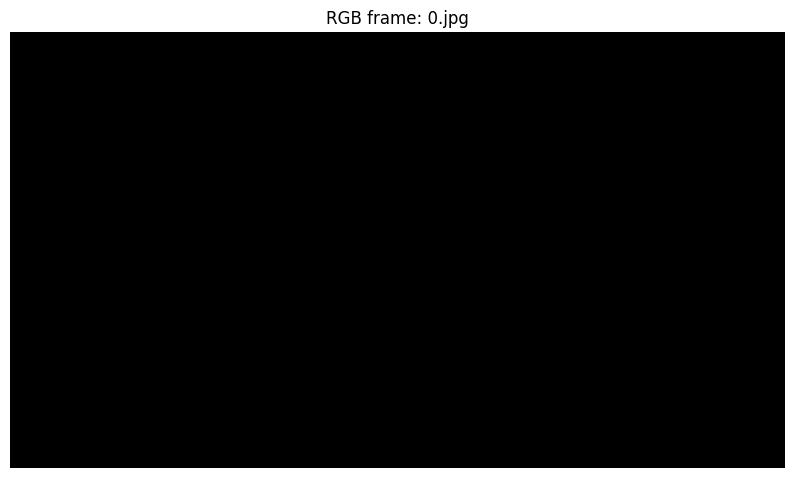

In [28]:
import cv2
import matplotlib.pyplot as plt

rgb_mp4 = SESSION_DIR / "L515_rgb.mp4"
rgb_images = SESSION_DIR / "rgb" / "images"

if rgb_images.exists() and any(rgb_images.iterdir()):
    frames = sorted(rgb_images.glob("*.jpg"))
    print(f"Pre-extracted frames: {len(frames)} JPEGs in rgb/images/")
    img = cv2.imread(str(frames[0]))
    print(f"Frame shape: {img.shape} (H, W, C)")
    plt.figure(figsize=(10, 6))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(f"RGB frame: {frames[0].name}")
    plt.axis("off")
    plt.show()

elif rgb_mp4.exists():
    cap = cv2.VideoCapture(str(rgb_mp4))
    n_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps = cap.get(cv2.CAP_PROP_FPS)
    w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    print(f"RGB video: {n_frames} frames, {fps:.1f} FPS, {w}x{h}")
    ret, frame = cap.read()
    cap.release()
    if ret:
        plt.figure(figsize=(10, 6))
        plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        plt.title("First RGB frame from L515_rgb.mp4")
        plt.axis("off")
        plt.show()
else:
    print("No RGB video or images found in this session.")

---
## 5. Depth Video: MP4 to 16-bit Depth Arrays

Depth data from the L515 LiDAR sensor is stored as `L515_depth.mp4` using
lossless **gray16le** encoding (16-bit grayscale). Standard OpenCV cannot
decode this format -- NERVE provides a custom ffmpeg-based reader:

```
nerve.extraction.utils.ffmpegReaders.VideoReader_x264
```

This wraps `ffmpeg-python` to decode frames as raw 16-bit numpy arrays.
The **depth unit** (meters per raw integer value) is stored in
`L515_depth_unit.txt` within each session.

Depth unit: 0.00025 meters/value
Frame shape: (720, 1280), dtype: uint16 (reconstructed)
Depth range: 0.06 - 6.81 m


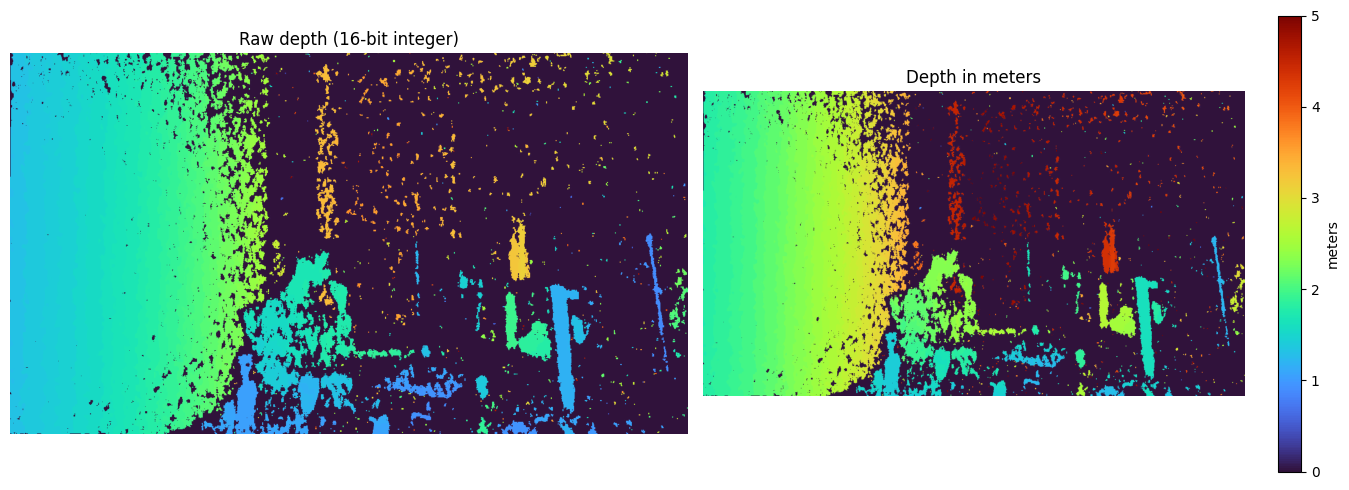

In [29]:
depth_mp4 = SESSION_DIR / "L515_depth.mp4"
depth_unit_file = SESSION_DIR / "L515_depth_unit.txt"

if depth_mp4.exists():
    depth_unit = 0.00025  # default
    if depth_unit_file.exists():
        depth_unit = float(depth_unit_file.read_text().strip())
    print(f"Depth unit: {depth_unit} meters/value")

    cap = cv2.VideoCapture(str(depth_mp4))
    ok, bgr = cap.read()
    cap.release()

    if ok:
        # gray16le is decoded as 3-channel BGR; reconstruct 16-bit from low + high byte
        depth16 = bgr[:, :, 0].astype(np.uint16) | (bgr[:, :, 1].astype(np.uint16) << 8)
        depth_meters = depth16.astype(np.float32) * depth_unit
        print(f"Frame shape: {depth16.shape}, dtype: uint16 (reconstructed)")
        print(f"Depth range: {depth_meters[depth_meters > 0].min():.2f} - "
              f"{depth_meters.max():.2f} m")

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        axes[0].imshow(depth16, cmap="turbo")
        axes[0].set_title("Raw depth (16-bit integer)")
        axes[0].axis("off")
        im = axes[1].imshow(depth_meters, cmap="turbo", vmin=0, vmax=5)
        axes[1].set_title("Depth in meters")
        axes[1].axis("off")
        plt.colorbar(im, ax=axes[1], label="meters")
        plt.tight_layout()
        plt.show()
    else:
        print("Could not read depth frame")
else:
    print(f"Not found: {depth_mp4}")


---
## 6. Event-to-Frame Representations

Once events are in HDF5 format, they can be converted into frame-like
tensor representations that standard CNNs and vision transformers can process.
NERVE implements four representation types in `nerve.processing.event_representations`:

| Representation | Channels | Description |
|----------------|----------|-------------|
| **Polarity histogram** | 2 | Positive/negative event counts per pixel in a time window |
| **VTEI** | `bins` | Volume of Ternary Event Images -- captures temporal dynamics |
| **Voxel grid** | 2 × `bins` | Discretised space-time volume |
| **Stacked histogram** | 2 × `bins` | Multiple histograms stacked over sub-intervals |
| **MDES** | `bins` | Mixed Density Event Stacks |

The simplest representation (polarity histogram) is built by
`nerve.processing.histogram`; the others by
`nerve.processing.event_representations`.

See `05_event_representations.ipynb` for an in-depth walkthrough with
visualisations.

Window: 254.19 -- 254.24 s  (13,267 events in 50.0 ms)


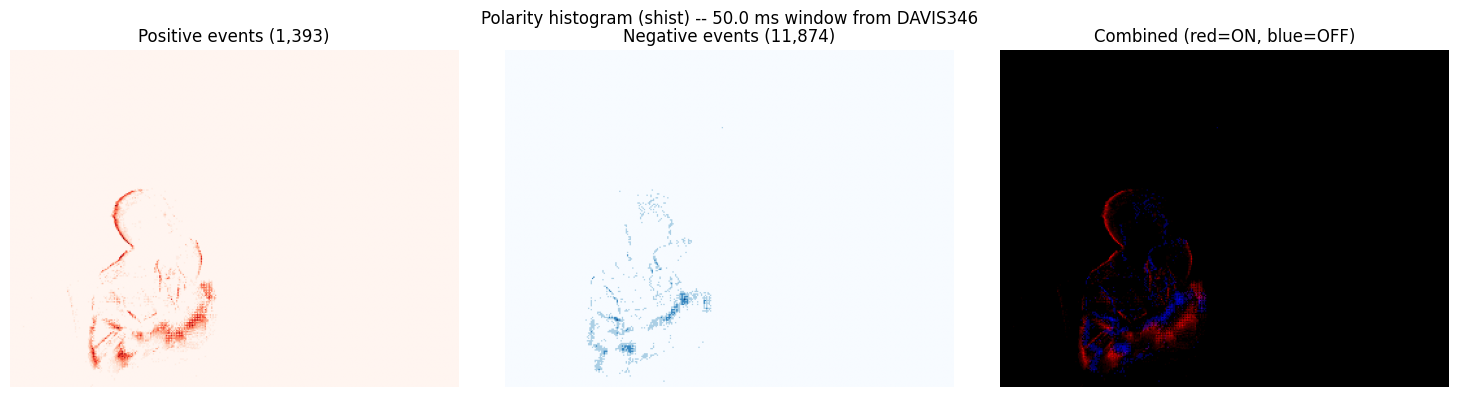

In [6]:
# Build a 2-channel polarity histogram using nerve.processing.event_representations
import h5py
import numpy as np
import matplotlib.pyplot as plt
from nerve.processing.event_representations import process_events

davis_hdf5 = SESSION_DIR / "davis" / "events.hdf5"
if davis_hdf5.exists():
    with h5py.File(davis_hdf5, "r") as f:
        ev = f["events"]
        width = int(ev.attrs.get("width", 346))
        height = int(ev.attrs.get("height", 260))
        t_all = ev["t"][:]

    # Pick a 50 ms window from the densest 1-second bin
    bin_edges = np.arange(t_all[0], t_all[-1], 1_000_000)
    counts, _ = np.histogram(t_all, bins=bin_edges)
    best_start = bin_edges[np.argmax(counts)]

    with h5py.File(davis_hdf5, "r") as f:
        ev = f["events"]
        lo = np.searchsorted(t_all, best_start)
        hi = np.searchsorted(t_all, best_start + 50_000)
        chunk = ev[lo:hi]

    window_ms = (chunk["t"][-1] - chunk["t"][0]) / 1000
    n_pos = int((chunk["p"] == 1).sum())
    n_neg = len(chunk) - n_pos
    print(f"Window: {chunk['t'][0]/1e6:.2f} -- {chunk['t'][-1]/1e6:.2f} s  "
          f"({len(chunk):,} events in {window_ms:.1f} ms)")

    hist = process_events(chunk, method="shist", bins=1,
                          height=height, width=width, force_cpu=True)
    if hasattr(hist, 'cpu'):
        hist = hist.cpu().numpy()
    hist = np.asarray(hist, dtype=np.float32)  # shape: (2, H, W)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].imshow(hist[0], cmap="Reds")
    axes[0].set_title(f"Positive events ({n_pos:,})")
    axes[1].imshow(hist[1], cmap="Blues")
    axes[1].set_title(f"Negative events ({n_neg:,})")
    combined = np.zeros((height, width, 3))
    combined[:, :, 0] = hist[0] / max(hist[0].max(), 1)
    combined[:, :, 2] = hist[1] / max(hist[1].max(), 1)
    axes[2].imshow(combined)
    axes[2].set_title("Combined (red=ON, blue=OFF)")
    for ax in axes:
        ax.axis("off")
    plt.suptitle(f"Polarity histogram (shist) -- {window_ms:.1f} ms window from DAVIS346")
    plt.tight_layout()
    plt.show()
else:
    print("DAVIS events.hdf5 not available.")


---
## 7. DVS Reconstruction: Events to Synthetic Images (E2VID)

For visualisation or models that need conventional intensity frames from
event cameras, NERVE includes an **E2VID** reconstruction pipeline
(`nerve.extraction.reconstruction`). This neural network maps sliding
windows of events to grayscale images.

```bash
python -m nerve.extraction.reconstruction.run_reconstruction \
    --input /data/session/davis/events.hdf5 \
    --output /data/session/davis/reconstructed/
```

The output PNG sequences can then be stitched into a video:

```bash
ffmpeg -framerate 60 -i reconstructed/%06d.png -c:v libx264 -pix_fmt yuv420p rec.mp4
```

> **Note:** E2VID reconstruction requires a pre-trained checkpoint and
> sufficient GPU memory. It is primarily used for qualitative inspection,
> not as an input to the training pipeline.

---
## Summary: Full Conversion Pipeline

```
Session archive (.tar.gz)
│
├── radar_and_davis346_events.rad ──→ davis/events.hdf5        [rad_polarities_to_hdf5]
│                                 ──→ Infineon radar ADC       [RadarFileParser]
├── evk4_events.raw              ──→ prophesee/events.hdf5     [raw_to_hdf5]
├── ti_radar/.../data.h5         ──→ point clouds / RD maps    [RadarBackend]
├── L515_rgb.mp4                 ──→ BGR frames                [OpenCV]
├── L515_depth.mp4               ──→ 16-bit depth arrays       [ffmpegReaders]
│
└── events.hdf5 (any camera)     ──→ VTEI / voxel / shist     [event_representations]
                                 ──→ polarity histogram PNGs   [histogram]
                                 ──→ reconstructed PNGs        [E2VID]

Note: The .rad file contains both Infineon Position2Go radar frames and
DAVIS346 events. The TI AWR1443BOOST radar is stored separately in ti_radar/.
```

All downstream code (label extraction, dataset generation, model training)
assumes the HDF5 conversions have already been performed. The session
archives distributed via 4TU **already include** the converted HDF5 files,
so most users will not need to run the converters manually. They are provided
for reproducibility and for processing new recordings. In general all the conversions and processing of raw data to compatible formats takes a long time and a lot of computational resources (up to 100s of GBs of RAM) so please be careful about using the raw processing pipelines.